In [1]:
import pandas as pd
import numpy as np
import json
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import datetime as DT
import io
from datetime import datetime, date 
from sklearn import metrics, preprocessing
from sklearn.preprocessing import StandardScaler, LabelEncoder, OrdinalEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, accuracy_score, f1_score, precision_score, recall_score,classification_report, jaccard_score, log_loss, roc_auc_score
from sklearn.model_selection import cross_val_score, GridSearchCV, train_test_split
from scipy import stats
import time
import itertools
import statsmodels.api as sm
from sklearn.impute import KNNImputer
import warnings 
warnings.filterwarnings('ignore')

## 1. Downloading data and creating dataframes:
    - merging train.json with train.csv and test.json with test.csv
    
## 2. Preparing data:
• Checking the data structure, statistics, and overall description

• Adding additional columns to the dataframes:

    - Groups (number of groups each user belongs to)

    - Age (calculated from the Date of Birth)

    - Location_type and Location_from_type (bins created based on location size)


• Handling missing data by:

    - Separating features into categorical and numerical variables

    - Removing rows with insufficient information

    - Filling missing values using mean/median/most frequent values

    - Inferring missing gender based on customer name (e.g., female names typically ending with “a”)

• Removing rows containing outlier values

    
## 3. Data visualizastion, summary
    - visualization of data
    - analysis of correlation
    - Splitting hobby column/ dummy data
    
## 4. Model building
    - preparing data sets - train and test dataframes
    
## 5. a) Logistic Regression
    - buidling ligistic regression model
    - creating confusion matrix
    - evaluation of model - checking accuracy, recall, f1, log loss
    - 
   ##  b) Making predictions on test dataframe using LR model
    - predicting target for users from test data set

## 6. a) Building Classification Decision Trees Classifier model
    - buidling decision tree model
    - creating confusion matrix
    - evaluation of model - checking accuracy, recall, f1, log loss
    
   ## b) Making predictions on test dataframe using Decision Tree model
    - predicting target for users from test data set
    
## 7. Summary

# Downloading and opening files

In [278]:
with open(r'C:\Users\kasia\OneDrive\Pulpit\udemy\Github\Accenture\train.json', encoding="utf8") as f:

   data = json.load(f)


In [279]:
with open(r'C:\Users\kasia\OneDrive\Pulpit\udemy\Github\Accenture\test.json', encoding="utf8") as f:

   data2 = json.load(f)


In [280]:
def flatten_json(nested_json, exclude=['']):
    """Flatten json object with nested keys into a single level.
        Args:
            nested_json: A nested json object.
            exclude: Keys to exclude from output.
        Returns:
            The flattened json object if successful, None otherwise.
    """
    out = {}

    def flatten(x, name='', exclude=exclude):
        if type(x) is dict:
            for a in x:
                if a not in exclude: flatten(x[a], name + a + '_')
        elif type(x) is list:
            i = 0
            for a in x:
                flatten(a, name + str(i) + '_')
                i += 1
        else:
            out[name[:-1]] = x

    flatten(nested_json)
    return out

In [281]:
train_j = pd.DataFrame([flatten_json(x) for x in data['data']])
test_j = pd.DataFrame([flatten_json(x) for x in data2['data']])

In [282]:
train_j.head()

,groups_data_0_group_name,groups_data_0_date_joined,groups_data_1_group_name,groups_data_1_date_joined,groups_data_2_group_name,groups_data_2_date_joined,groups_data_3_group_name,groups_data_3_date_joined,id,groups_data_4_group_name,...,groups_data_6_group_name,groups_data_6_date_joined,groups_data_7_group_name,groups_data_7_date_joined,groups_data_8_group_name,groups_data_8_date_joined,groups_data_9_group_name,groups_data_9_date_joined,groups_data_10_group_name,groups_data_10_date_joined
0,Let's excercise together and lose a few kilo q...,2008-09-05 09:55:18.730066,Strongman competition,2008-05-22 21:25:22.572365,Fast food 4 life,2012-02-02 05:26:01.293628,alternative medicine - Hypnosis and bioenergot...,2008-07-05 05:47:12.254848,0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Tom Cruise group,2009-06-14 16:48:28.606142,Babysitters (Sokółka),2010-09-25 03:21:01.944684,Work abroad - join to find well paid work and ...,2010-09-21 23:44:39.499240,"Tennis, Squash, Badminton, table tennis - look...",2007-10-09 17:15:13.896508,1,Lost&Found (Sokółka),...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Polish wildlife - best places,2007-07-29 18:15:49.603727,Politics and politicians,2010-10-03 21:00:27.154597,Pizza ! Best recipes,2010-08-25 22:26:48.331266,Animal rights group - join us if you care!,2010-11-02 12:41:37.753989,2,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,The Aspiring Writer,2009-09-08 15:49:57.132171,Nutrition & food advices,2010-12-02 18:19:30.887307,Game of thrones,2009-09-18 10:00:16.190795,NaN,NaN,3,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,The ultimate house and electro group,2008-01-02 14:57:39.269135,Pirates of the Carribean,2012-03-05 03:28:37.972484,Musicians Available Poland (Osieczna),2009-12-21 13:48:10.887986,Housekeeping - looking for a housekeeper ? Joi...,2008-10-28 23:22:26.159789,4,Rooms for rent (Osieczna),...,Nutrition & food advices,2011-02-08 19:38:58.932003,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


# 2. Preparing data, data wrangling

### Adding New Column - Group

In [283]:
#columns with dates won't be useful - they will be remnoved
columns_to_drop = [col for col in train_j.columns if 'date_joined' in col]
train_groups = train_j.drop(columns=columns_to_drop)
# In further analysis and model development, the number of groups each customer belongs to may be an important feature.
# Creating a new column "groups" that counts the number of groups associated with each individual.
train_groups['groups'] = train_groups.count(axis=1) -1
train_groups.head(3)

,groups_data_0_group_name,groups_data_1_group_name,groups_data_2_group_name,groups_data_3_group_name,id,groups_data_4_group_name,groups_data_5_group_name,groups_data_6_group_name,groups_data_7_group_name,groups_data_8_group_name,groups_data_9_group_name,groups_data_10_group_name,groups
0,Let's excercise together and lose a few kilo q...,Strongman competition,Fast food 4 life,alternative medicine - Hypnosis and bioenergot...,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4
1,Tom Cruise group,Babysitters (Sokółka),Work abroad - join to find well paid work and ...,"Tennis, Squash, Badminton, table tennis - look...",1,Lost&Found (Sokółka),NaN,NaN,NaN,NaN,NaN,NaN,5
2,Polish wildlife - best places,Politics and politicians,Pizza ! Best recipes,Animal rights group - join us if you care!,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4


In [284]:
#same steps for test data set
columns_to_drop = [col for col in test_j.columns if 'date_joined' in col]
test_groups = test_j.drop(columns=columns_to_drop)

test_groups['groups'] = test_groups.count(axis=1) -1
test_groups.head(3)

,groups_data_0_group_name,groups_data_1_group_name,groups_data_2_group_name,id,groups_data_3_group_name,groups_data_4_group_name,groups_data_5_group_name,groups_data_6_group_name,groups_data_7_group_name,groups_data_8_group_name,groups_data_9_group_name,groups
0,Wedding planning - places and bands (and other...,Harry Potter and the Deathly Hollows,"Xbox , Playstation, Wii - console fans",0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3
1,Lost&Found (Strzegom),"Tennis, Squash, Badminton, table tennis - look...",Weightlifting - group for amateurs (Strzegom),1,Tarty mountains - hikers group,Life pro tips,The calse dancing group (Strzegom),"Octavia, Fabia, Roomster - Skoda lovers group",NaN,NaN,NaN,7
2,Cooking - italian cuisine,Tutoring - will teach / looking for a tutor (B...,Technical School of Electronics (Bielawa),2,"Young, fit and healthy - active livestyle = he...",Morgan Freeman - fangroup,NaN,NaN,NaN,NaN,NaN,5


In [285]:
train= pd.read_csv(r"C:\Users\kasia\OneDrive\Pulpit\udemy\Github\Accenture\train.csv")
test= pd.read_csv(r"C:\Users\kasia\OneDrive\Pulpit\udemy\Github\Accenture\test.csv")

In [286]:
train.head(3)

,user_id,target,name,sex,dob,location,location_population,location_from,location_from_population,occupation,hobbies,daily_commute,friends_number,relationship_status,education,credit_card_type
0,0,1,Halina,NaN,1982-08-07,Piastów,22732,Piastów,22732,Teaching professionals,Fitness,46.0,196,Single,NaN,Visa
1,1,0,Eustachy,male,1971-10-28,Sokółka,18331,Sokółka,18331,General and keyboard clerks,"LARPing,Foreign language learning,Netball",55.0,243,Single,NaN,NaN
2,2,1,Egon,NaN,2000-07-05,Łaskarzew,4879,Łaskarzew,4879,Protective services workers,"Bodybuilding,Kabaddi",90.0,191,In relationship,3.0,NaN


In [287]:
test.head(3)

,user_id,target,name,sex,dob,location,location_population,location_from,location_from_population,occupation,hobbies,daily_commute,friends_number,relationship_status,education,credit_card_type
0,0,NaN,Dawid,male,1973-03-15,Kąty Wrocławskie,6846,Trzebinia,19954,Numerical and material recording clerks,Stretching,NaN,146,Single,1.0,Visa
1,1,NaN,Adam,male,1991-04-06,Strzegom,16272,Poznań,538633,"Food processing, wood working, garment and oth...","Gym,Kettleballs,Jewelry making",NaN,209,Married with kids,2.0,Visa
2,2,NaN,Adela,female,NaN,Bielawa,30207,Bielawa,30207,Health professionals,Fashion,39.0,213,Married,4.0,Visa


In [288]:
train_groups['id']=train_groups['id'].astype(int)
train_groups.id.dtype

dtype('int32')

In [289]:
train = pd.merge(train, train_groups[['id', 'groups']], left_on='user_id', right_on='id', how = 'left')
train.drop('id', axis=1, inplace=True)

In [290]:
train.head(3)

,user_id,target,name,sex,dob,location,location_population,location_from,location_from_population,occupation,hobbies,daily_commute,friends_number,relationship_status,education,credit_card_type,groups
0,0,1,Halina,NaN,1982-08-07,Piastów,22732,Piastów,22732,Teaching professionals,Fitness,46.0,196,Single,NaN,Visa,4
1,1,0,Eustachy,male,1971-10-28,Sokółka,18331,Sokółka,18331,General and keyboard clerks,"LARPing,Foreign language learning,Netball",55.0,243,Single,NaN,NaN,5
2,2,1,Egon,NaN,2000-07-05,Łaskarzew,4879,Łaskarzew,4879,Protective services workers,"Bodybuilding,Kabaddi",90.0,191,In relationship,3.0,NaN,4


In [291]:
#Train data has 17 columns and 4000 rows (16 attributes/variables and 4000 observations)
train.shape

(4000, 17)

In [292]:
test_groups['id']=test_groups['id'].astype(int)
test = pd.merge(test, test_groups[['id', 'groups']], left_on='user_id', right_on='id', how = 'left')
test.drop('id', axis=1, inplace=True)

In [293]:
#Train data has 17 columns and 2000 rows (16 attributes/variables and 2000 observations)
test.shape

(2000, 17)

In [294]:
train.describe(include = "all")

,user_id,target,name,sex,dob,location,location_population,location_from,location_from_population,occupation,hobbies,daily_commute,friends_number,relationship_status,education,credit_card_type,groups
count,4000.000000,4000.000000,3982,3616,3606,4000,4.000000e+03,4000,4.000000e+03,4000,3320,3595.000000,4000.000000,3607,3592.000000,3572,4000.000000
unique,NaN,NaN,205,2,3242,645,NaN,650,NaN,43,2745,NaN,NaN,5,NaN,4,NaN
top,NaN,NaN,Franciszek,female,2000-03-20,Warszawa,NaN,Warszawa,NaN,Science and engineering associate professionals,Gym,NaN,NaN,In relationship,NaN,Visa,NaN
freq,NaN,NaN,38,2040,4,332,NaN,306,NaN,106,20,NaN,NaN,1247,NaN,1777,NaN
mean,1999.500000,0.201500,NaN,NaN,NaN,NaN,3.105877e+05,NaN,2.910267e+05,NaN,NaN,50.098748,199.877750,NaN,3.670935,NaN,4.029500
std,1154.844867,0.401171,NaN,NaN,NaN,NaN,4.878360e+05,NaN,4.717641e+05,NaN,NaN,28.806060,90.494937,NaN,1.327582,NaN,1.788695
min,0.000000,0.000000,NaN,NaN,NaN,NaN,7.860000e+02,NaN,1.031000e+03,NaN,NaN,0.000000,0.000000,NaN,1.000000,NaN,0.000000
25%,999.750000,0.000000,NaN,NaN,NaN,NaN,2.435725e+04,NaN,2.422050e+04,NaN,NaN,25.000000,143.000000,NaN,3.000000,NaN,3.000000
50%,1999.500000,0.000000,NaN,NaN,NaN,NaN,8.007200e+04,NaN,7.379100e+04,NaN,NaN,50.000000,199.000000,NaN,4.000000,NaN,4.000000
75%,2999.250000,0.000000,NaN,NaN,NaN,NaN,3.523130e+05,NaN,3.398500e+05,NaN,NaN,75.000000,256.000000,NaN,5.000000,NaN,5.000000


<Axes: xlabel='target', ylabel='count'>

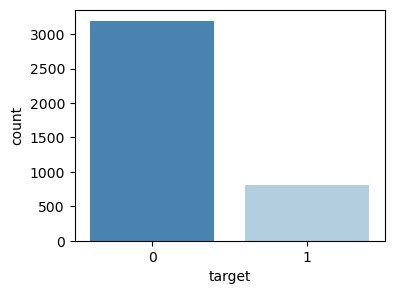

In [295]:
# Count of target variable - term deposit subscribes: 'yes' or 'no'
plt.figure(figsize=(4, 3))
sns.countplot(x = 'target', data = train, palette = 'Blues_r')

## Adding column with age

In [296]:
df_list = [train, test]
now = pd.Timestamp('now')

In [297]:
for df in df_list:
    df['dob'] = pd.to_datetime(df['dob'], format='%Y/%m/%d')
    df['dob'] = df['dob'].where(df['dob'] < now, df['dob'] - np.timedelta64(100, 'Y'))
    df['age'] = (now - df['dob']).astype('<m8[Y]')

In [298]:
#dropping column DOB as it won't be useful
train.drop('dob', axis=1, inplace=True)

In [299]:
train.head()

,user_id,target,name,sex,location,location_population,location_from,location_from_population,occupation,hobbies,daily_commute,friends_number,relationship_status,education,credit_card_type,groups,age
0,0,1,Halina,NaN,Piastów,22732,Piastów,22732,Teaching professionals,Fitness,46.0,196,Single,NaN,Visa,4,43.0
1,1,0,Eustachy,male,Sokółka,18331,Sokółka,18331,General and keyboard clerks,"LARPing,Foreign language learning,Netball",55.0,243,Single,NaN,NaN,5,54.0
2,2,1,Egon,NaN,Łaskarzew,4879,Łaskarzew,4879,Protective services workers,"Bodybuilding,Kabaddi",90.0,191,In relationship,3.0,NaN,4,25.0
3,3,0,Eulalia,female,Bydgoszcz,352313,Bydgoszcz,352313,Customer services clerks,Badminton,88.0,164,In relationship,3.0,Visa,3,33.0
4,4,0,Hilary,NaN,Osieczna,2322,Poznań,538633,Refuse workers and other elementary workers,"Fitness,Embroidery,Lacemaking",40.0,119,Married with kids,5.0,NaN,7,50.0


## Adding columns - location_type, location_from_type
If the numeric column contains a wide range of values (population), binning can simplify the complexity of the data and make it more manageable. Binning can help capture non-linear relationships between the numeric variable and the target variable.  categorizing the numeric values into bins, may uncover patterns or relationships that would be difficult to detect using the raw numeric values alone. Binning can reduce the impact of outliers or extreme values in the numeric column. This can help improve the robustness of the model and make it less sensitive to extreme observations.

New groups and their corresponding ranges of population:

- (4) Large City >200000
- (3) Midsize City> 50000
- (2) Small City >2000
- (1) Rural<2000

In [300]:
#checking distribution of population data using quantiles
train['location_population'].quantile([0.25,0.5,0.75])

0.25     24357.25
0.50     80072.00
0.75    352313.00
Name: location_population, dtype: float64

In [301]:
train['location_from_population'].quantile([0.25,0.5,0.75])

0.25     24220.5
0.50     73791.0
0.75    339850.0
Name: location_from_population, dtype: float64

In [302]:
bins = [0, 2000, 50000, 200000, 2000000]

In [303]:
for df in df_list:
    df['location_type'] = pd.cut(df['location_population'].values, bins,labels = [1, 2, 3, 4])
    df['location_from_type'] = pd.cut(df['location_from_population'].values, bins,labels = [1, 2, 3, 4])

In [304]:
test.head(3)

,user_id,target,name,sex,dob,location,location_population,location_from,location_from_population,occupation,hobbies,daily_commute,friends_number,relationship_status,education,credit_card_type,groups,age,location_type,location_from_type
0,0,NaN,Dawid,male,1973-03-15,Kąty Wrocławskie,6846,Trzebinia,19954,Numerical and material recording clerks,Stretching,NaN,146,Single,1.0,Visa,3,52.0,2,2
1,1,NaN,Adam,male,1991-04-06,Strzegom,16272,Poznań,538633,"Food processing, wood working, garment and oth...","Gym,Kettleballs,Jewelry making",NaN,209,Married with kids,2.0,Visa,7,34.0,2,4
2,2,NaN,Adela,female,NaT,Bielawa,30207,Bielawa,30207,Health professionals,Fashion,39.0,213,Married,4.0,Visa,5,NaN,2,2


In [305]:
train.head(3)

,user_id,target,name,sex,location,location_population,location_from,location_from_population,occupation,hobbies,daily_commute,friends_number,relationship_status,education,credit_card_type,groups,age,location_type,location_from_type
0,0,1,Halina,NaN,Piastów,22732,Piastów,22732,Teaching professionals,Fitness,46.0,196,Single,NaN,Visa,4,43.0,2,2
1,1,0,Eustachy,male,Sokółka,18331,Sokółka,18331,General and keyboard clerks,"LARPing,Foreign language learning,Netball",55.0,243,Single,NaN,NaN,5,54.0,2,2
2,2,1,Egon,NaN,Łaskarzew,4879,Łaskarzew,4879,Protective services workers,"Bodybuilding,Kabaddi",90.0,191,In relationship,3.0,NaN,4,25.0,2,2


# Handling missing data
Handling missing data and outliers is crucial for preparing data for model building. Most common way of replacing missing values is with a suitable estimate such as mean, median or mode. Rows/columns can be also removed if the missingness is random and not substantial.

In [306]:
#checking how many data is missing in each column
train.isnull().sum()

user_id                       0
target                        0
name                         18
sex                         384
location                      0
location_population           0
location_from                 0
location_from_population      0
occupation                    0
hobbies                     680
daily_commute               405
friends_number                0
relationship_status         393
education                   408
credit_card_type            428
groups                        0
age                         394
location_type                 0
location_from_type            0
dtype: int64

In [307]:
test.isnull().sum()

user_id                        0
target                      2000
name                           6
sex                          191
dob                          191
location                       0
location_population            0
location_from                  0
location_from_population       0
occupation                     0
hobbies                      316
daily_commute                204
friends_number                 0
relationship_status          230
education                    183
credit_card_type             205
groups                         0
age                          191
location_type                  0
location_from_type             0
dtype: int64

## Column sex - based on the name
Female names end with letter "a". Based on name we can find wgat sex should be assigned for each user. 

In [308]:
#checking how many users are men and women 
train['sex'].value_counts()

female    2040
male      1576
Name: sex, dtype: int64

In [309]:
df_list = [train, test]

In [310]:
#filling missing data in sex column where the name is female
for df in df_list:
    sex_na = df[df.sex.isna()] 
    sex_na = sex_na[['name', 'sex']]
    sex_na = sex_na[sex_na['name'].notna()]
    
    #selecting all female names - all names that ends with letter "a" are female
    sex_na_f = sex_na[sex_na['name'].str.endswith('a')]
    
    #making a list of indexes where name is female  
    index_female = sex_na_f['sex'].index.values.tolist()
   
    #applying changes in dfs
    df.loc[index_female, 'sex'] = df.loc[index_female, 'sex'].fillna(value='female')
    

In [311]:
#we can see that the number of females increased by 203
train['sex'].value_counts()

female    2243
male      1576
Name: sex, dtype: int64

In [312]:
#there is still 181 observations left
train['sex'].isna().value_counts()

False    3819
True      181
Name: sex, dtype: int64

In [313]:
#filling missing data for male names
for df in df_list:
    sex_male = df[df['sex'].isna()]
    sex_male = sex_male[sex_male['name'].notna()]
    index_sex_m = sex_male.index.values.tolist()
    df.loc[index_sex_m, 'sex'] = df.loc[index_sex_m, 'sex'].fillna(value='male')

In [314]:
#there is still one observation with missing value
train['sex'].isna().value_counts()

False    3999
True        1
Name: sex, dtype: int64

In [315]:
train['sex'].value_counts()

female    2243
male      1756
Name: sex, dtype: int64

In [316]:
train[train['sex'].isnull()]

,user_id,target,name,sex,location,location_population,location_from,location_from_population,occupation,hobbies,daily_commute,friends_number,relationship_status,education,credit_card_type,groups,age,location_type,location_from_type
2925,2925,0,NaN,NaN,Warszawa,1764615,Warszawa,1764615,Administrative and commercial managers,"Skiing,Shopping",81.0,166,In relationship,NaN,Visa,4,65.0,4,4


In [317]:
#due to lack of the name we can't establish gender. The missing value will be replaces with most frequent value - "female"
for df in df_list:
    df['sex'].replace(np.nan, "female", inplace=True)

# Using KNN Imputer for missing data

KNN imputer identifies nearest neighbors based on the overall similarity of data points in the feature space. It leverages the collective information from neighboring data points to impute missing values, even if there is no direct correlation between variables. KNN imputer is flexible and can handle various data distributions and relationships between variables. It does not assume specific distributions or relationships, making it suitable for datasets with diverse characteristics, including those with no correlation between variables.

# Numercial features - daily commute, friends number and age
analyzing the numerical features (daily_commute, friends_number, age) by generating descriptive statistics, computing their correlation matrix, and visualizing their distributions using histograms with KDE. These plots help identify data patterns, detect outliers, and understand the overall behavior of the numerical variables.

In [318]:
numerical_features=['daily_commute', 'friends_number', 'age']
train[numerical_features]=train[numerical_features].astype(float)

In [319]:
train[numerical_features].describe().round()

,daily_commute,friends_number,age
count,3595.0,4000.0,3606.0
mean,50.0,200.0,46.0
std,29.0,90.0,14.0
min,0.0,0.0,24.0
25%,25.0,143.0,36.0
50%,50.0,199.0,46.0
75%,75.0,256.0,56.0
max,99.0,619.0,103.0


In [320]:
train[numerical_features].corr()

,daily_commute,friends_number,age
daily_commute,1.000000,0.001117,0.015304
friends_number,0.001117,1.000000,0.026362
age,0.015304,0.026362,1.000000


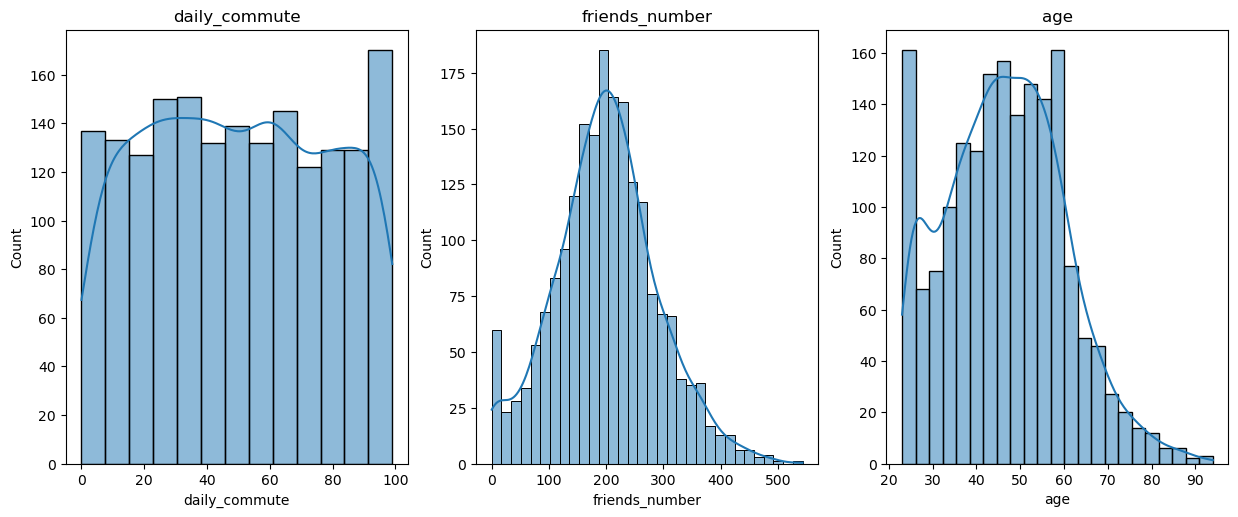

In [321]:
plt.figure(figsize=(15,80))
plotnumber = 1
for numerical_feature in numerical_features:
    ax = plt.subplot(12,3,plotnumber)
    sns.histplot(x = numerical_feature,data = df,kde=True)
    plt.title(numerical_feature)
    plotnumber+=1
plt.show()

In [322]:
selected_data =train[numerical_features]

In [323]:
knn_imputer = KNNImputer(n_neighbors = 5)
imputed_data = knn_imputer.fit_transform(selected_data)
imputed_df= pd.DataFrame(imputed_data, columns=numerical_features)

In [324]:
imputed_df

,daily_commute,friends_number,age
0,46.0,196.0,43.0
1,55.0,243.0,54.0
2,90.0,191.0,25.0
3,88.0,164.0,33.0
4,40.0,119.0,50.0
...,...,...,...
3995,1.0,126.0,40.0
3996,65.0,121.0,40.0
3997,79.0,140.0,59.0
3998,30.0,272.0,54.0


In [325]:
train[numerical_features] = imputed_df

In [326]:
train[numerical_features].isnull().sum()

daily_commute     0
friends_number    0
age               0
dtype: int64

In [327]:
#we can see that KNN didn't affect much statistic measures of numeric variables
train[numerical_features].describe().round()

,daily_commute,friends_number,age
count,4000.0,4000.0,4000.0
mean,50.0,200.0,46.0
std,28.0,90.0,13.0
min,0.0,0.0,24.0
25%,27.0,143.0,37.0
50%,50.0,199.0,46.0
75%,73.0,256.0,55.0
max,99.0,619.0,103.0


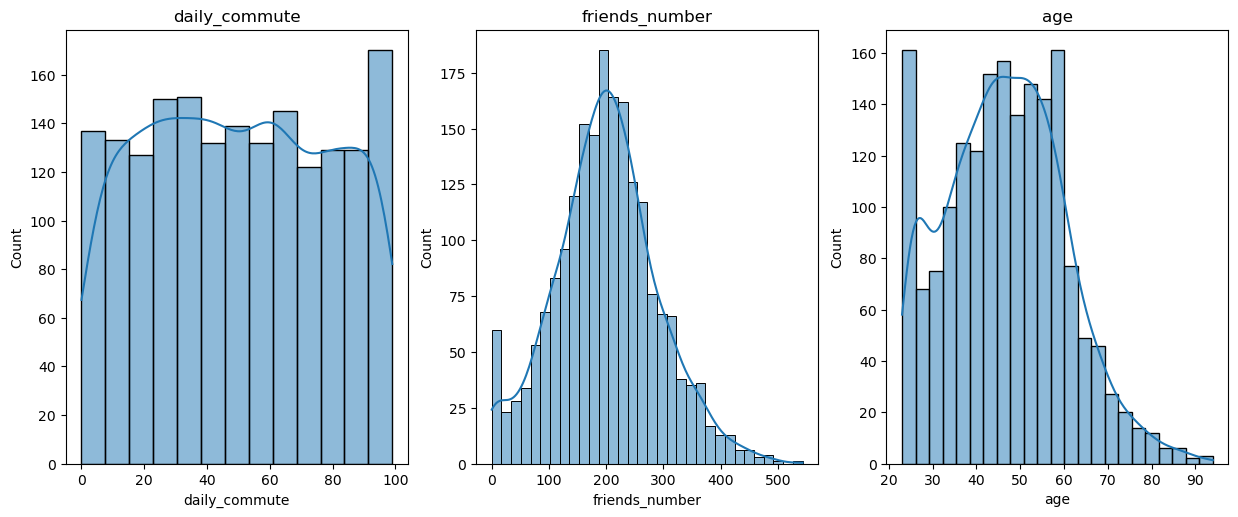

In [328]:
plt.figure(figsize=(15,80))
plotnumber = 1
for numerical_feature in numerical_features:
    ax = plt.subplot(12,3,plotnumber)
    sns.histplot(x = numerical_feature,data = df,kde=True)
    plt.title(numerical_feature)
    plotnumber+=1
plt.show()

In [329]:
#same for test
test[numerical_features]=train[numerical_features].astype(float)
selected_data =train[numerical_features]
test[numerical_features] = imputed_df
test[numerical_features].isnull().sum()

daily_commute     0
friends_number    0
age               0
dtype: int64

# Categorical features - relationship_status, education, credit_card_type

In [330]:
categorical_features=['relationship_status', 'education', 'credit_card_type']

In [331]:
encoded_features = train[['relationship_status', 'credit_card_type']]

In [332]:
train.head()

,user_id,target,name,sex,location,location_population,location_from,location_from_population,occupation,hobbies,daily_commute,friends_number,relationship_status,education,credit_card_type,groups,age,location_type,location_from_type
0,0,1,Halina,female,Piastów,22732,Piastów,22732,Teaching professionals,Fitness,46.0,196.0,Single,NaN,Visa,4,43.0,2,2
1,1,0,Eustachy,male,Sokółka,18331,Sokółka,18331,General and keyboard clerks,"LARPing,Foreign language learning,Netball",55.0,243.0,Single,NaN,NaN,5,54.0,2,2
2,2,1,Egon,male,Łaskarzew,4879,Łaskarzew,4879,Protective services workers,"Bodybuilding,Kabaddi",90.0,191.0,In relationship,3.0,NaN,4,25.0,2,2
3,3,0,Eulalia,female,Bydgoszcz,352313,Bydgoszcz,352313,Customer services clerks,Badminton,88.0,164.0,In relationship,3.0,Visa,3,33.0,4,4
4,4,0,Hilary,male,Osieczna,2322,Poznań,538633,Refuse workers and other elementary workers,"Fitness,Embroidery,Lacemaking",40.0,119.0,Married with kids,5.0,NaN,7,50.0,2,4


This step performs label encoding of categorical variables in the training dataset.
For each feature listed in encoded_features, the code:

1. Identifies non-null entries to avoid encoding missing values.

2. Fits a LabelEncoder on the non-null subset of the feature.

3. Transforms the non-null values into integer labels and writes them back into the dataframe.

4. Prints the encoding dictionary (class to integer) for transparency and potential reuse.

This ensures that categories are encoded consistently and missing data remains unaffected by the transformation.

In [333]:

le = LabelEncoder()

for feature in encoded_features:
    print(feature)
    nonnull_indices = train[feature].notnull()
    nonnull_data = train.loc[nonnull_indices, feature]
    train.loc[nonnull_indices, feature] = le.fit_transform(nonnull_data)
    integer_mapping = {l: i for i, l in enumerate(le.classes_)}
    # Create integer mapping for the non-null data
    print(integer_mapping)
    print()


relationship_status
{'Divorced': 0, 'In relationship': 1, 'Married': 2, 'Married with kids': 3, 'Single': 4}

credit_card_type
{'American Express': 0, 'Mastercard': 1, 'Revolut': 2, 'Visa': 3}



In [334]:
train['relationship_status'].value_counts()

1    1247
2     830
3     749
4     585
0     196
Name: relationship_status, dtype: int64

This step visualizes the distribution of all categorical features in the dataset.
For each categorical variable, a horizontal count plot is generated, showing the frequency of each category.
The plots are to identify imbalances, rare categories, or potential issues in the data.

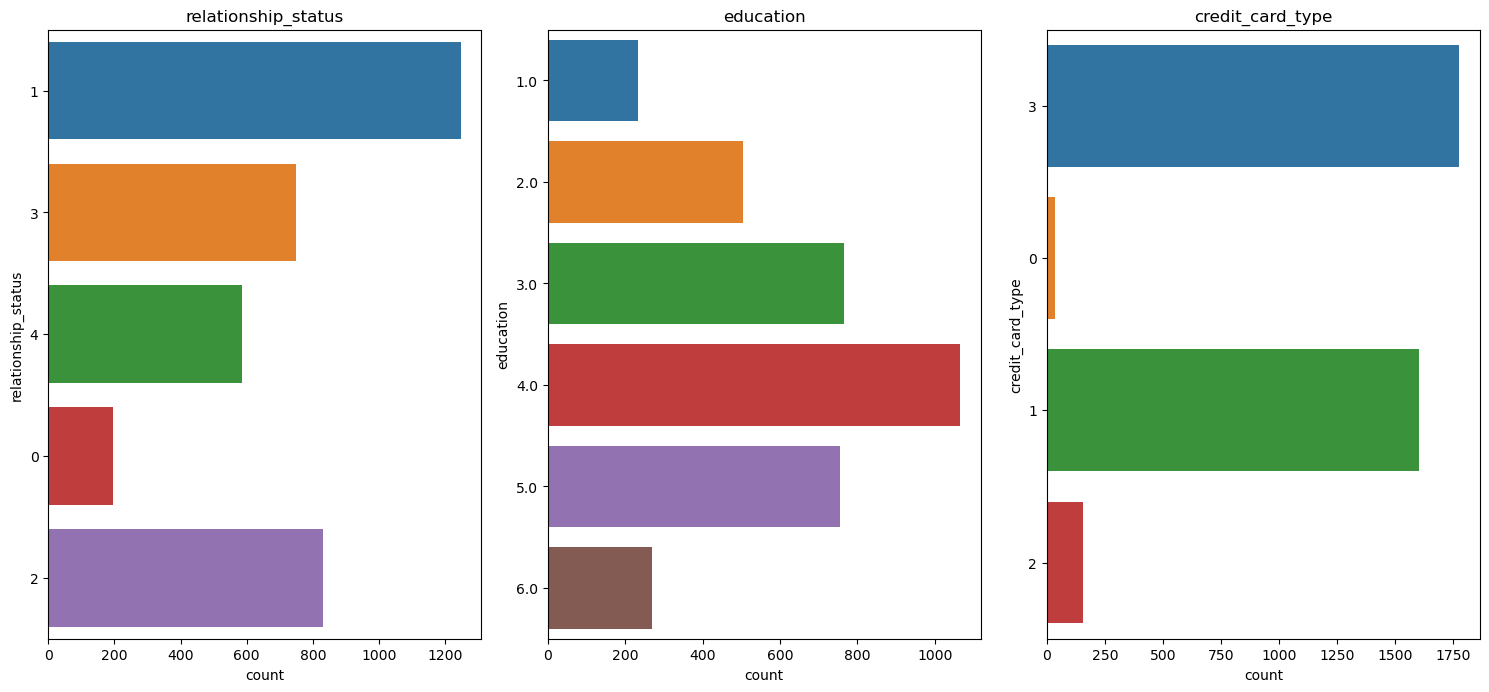

In [335]:
plt.figure(figsize=(15,80))
plotnumber = 1
for categorical_feature in categorical_features:
    ax = plt.subplot(12,3,plotnumber)
    sns.countplot(y = categorical_feature,data = train)
    plt.title(categorical_feature)
    plotnumber+=1
plt.tight_layout()
plt.show()

This step applies K-Nearest Neighbors (KNN) imputation to fill missing values in the categorical features.
The imputer identifies the 5 nearest samples (based on feature similarity) and uses them to estimate and replace missing values.
Because KNN returns numerical outputs, the results are rounded and converted back into a dataframe with the original feature names.

In [336]:
selected_data = train[categorical_features]
knn_imputer = KNNImputer(n_neighbors = 5)
imputed_data = np.round(knn_imputer.fit_transform(selected_data))
imputed_df= pd.DataFrame(imputed_data, columns=categorical_features)
imputed_df

,relationship_status,education,credit_card_type
0,4.0,3.0,3.0
1,4.0,4.0,2.0
2,1.0,3.0,2.0
3,1.0,3.0,3.0
4,3.0,5.0,2.0
...,...,...,...
3995,2.0,5.0,1.0
3996,4.0,2.0,3.0
3997,4.0,4.0,3.0
3998,0.0,6.0,1.0


In [337]:
imputed_df['relationship_status'].value_counts()

1.0    1302
2.0    1073
3.0     844
4.0     585
0.0     196
Name: relationship_status, dtype: int64

In [338]:
train[categorical_features] = imputed_df

In [339]:
train[categorical_features].describe().round()

,relationship_status,education,credit_card_type
count,4000.0,4000.0,4000.0
mean,2.0,4.0,2.0
std,1.0,1.0,1.0
min,0.0,1.0,0.0
25%,1.0,3.0,1.0
50%,2.0,4.0,2.0
75%,3.0,5.0,3.0
max,4.0,6.0,3.0


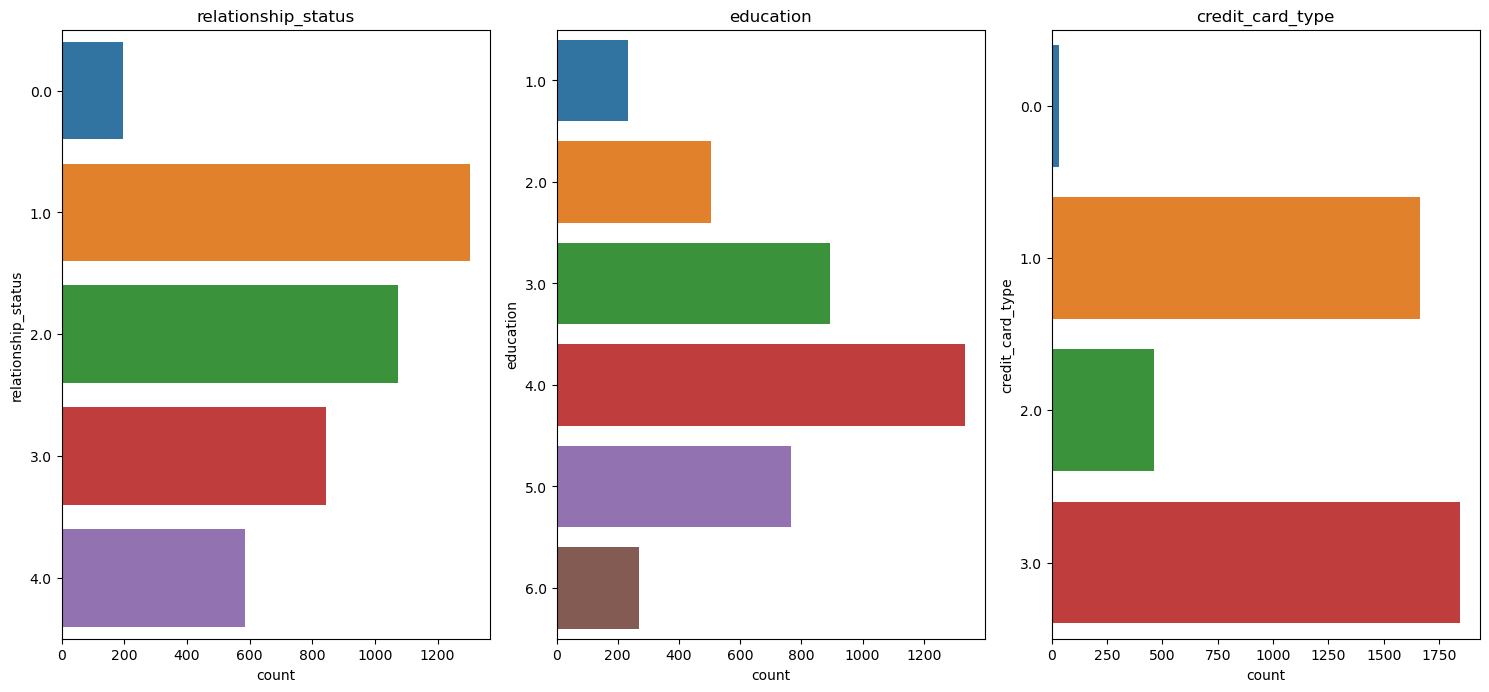

In [340]:
# new plot 
plt.figure(figsize=(15,80))
plotnumber = 1
for categorical_feature in categorical_features:
    ax = plt.subplot(12,3,plotnumber)
    sns.countplot(y = categorical_feature,data = train)
    plt.title(categorical_feature)
    plotnumber+=1
plt.tight_layout()
plt.show()

In [341]:
selected_data = test[categorical_features]
imputed_df= pd.DataFrame(imputed_data, columns=categorical_features)
test[categorical_features] = imputed_df

# Handling Outliers
This step visualizes potential outliers in the numerical features (daily_commute, friends_number, age) using boxplots.
The plots help identify extreme values and understand the spread and variability within each feature, which supports further outlier handling using methods such as the Z-Score approach.

## boxplots and Z-Score Method

In [342]:
#checking outliers for few columns
outlier_check = ['daily_commute', 'friends_number', 'age']

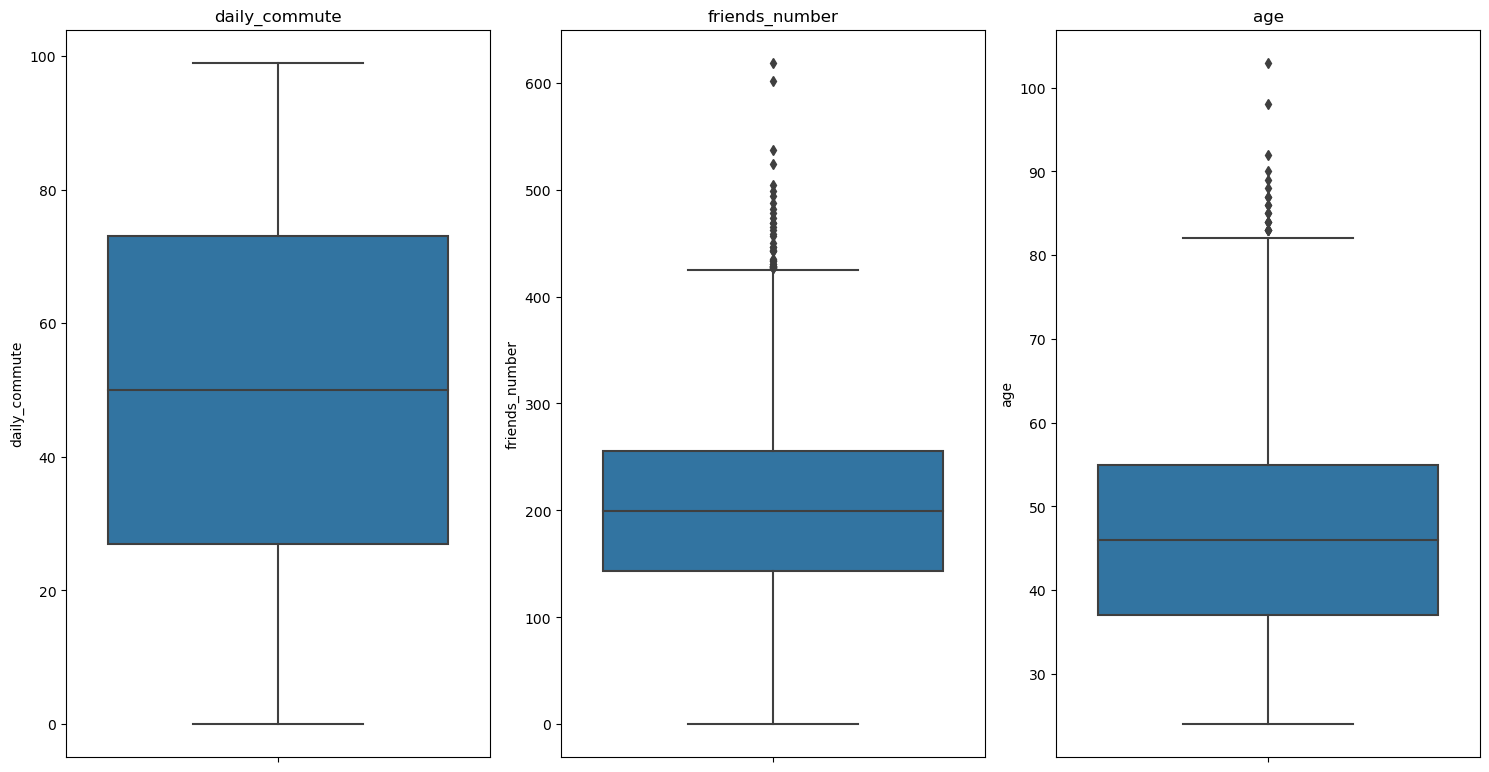

In [343]:
plt.figure(figsize=(15,90))
plotnumber = 1
for outliers in outlier_check:
    ax = plt.subplot(12,3,plotnumber)
    sns.boxplot(y = outliers, data = train)
    plt.title(outliers)
    plotnumber+=1
plt.tight_layout()
plt.show()

We can see that in friends_number and age have some outliers.

## Z-Score Method
Outliers were detected using the Z-score method for the numerical features daily_commute, friends_number, and age.
A threshold of |z| > 3 was applied, and observations exceeding this limit were identified and removed.
Boxplots before and after cleaning were used to visually confirm that extreme values were successfully eliminated without significantly reducing the dataset size.


In [344]:
z_scores = stats.zscore(train[outlier_check])

In [345]:
z_scores 

,daily_commute,friends_number,age
0,-0.151537,-0.042856,-0.258888
1,0.173918,0.476575,0.586448
2,1.439577,-0.098114,-1.642166
3,1.367254,-0.396511,-1.027376
4,-0.368508,-0.893839,0.279053
...,...,...,...
3995,-1.778813,-0.816476,-0.489434
3996,0.535535,-0.871735,-0.489434
3997,1.041798,-0.661752,0.970692
3998,-0.730124,0.797075,0.586448


In [346]:
threshold = 3

In [347]:
age_z = z_scores[z_scores['age']>3]

In [348]:
#outliers for age column
train.loc[age_z.index, 'age']

376      98.0
833      87.0
1610     89.0
2043     86.0
2512    103.0
3035     90.0
3111     92.0
3269     88.0
3465     87.0
3612     86.0
Name: age, dtype: float64

In [349]:
friends_number_z = z_scores[z_scores['friends_number']>3]
#outliers for friends_number column
train.loc[friends_number_z.index, 'friends_number']

21      482.0
442     474.0
511     537.0
988     602.0
1123    619.0
2136    488.0
2262    504.0
2708    524.0
3299    499.0
3321    478.0
3357    494.0
Name: friends_number, dtype: float64

In [350]:
#no Outliers for daily commute
daily_commute_z = z_scores[z_scores['daily_commute']>3]
#outliers for friends_number column
train.loc[daily_commute_z.index, 'daily_commute']

Series([], Name: daily_commute, dtype: float64)

In [351]:
train.drop(age_z.index , axis=0, inplace=True)

In [352]:
train.drop(friends_number_z.index , axis=0, inplace=True)

In [353]:
train.shape

(3979, 19)

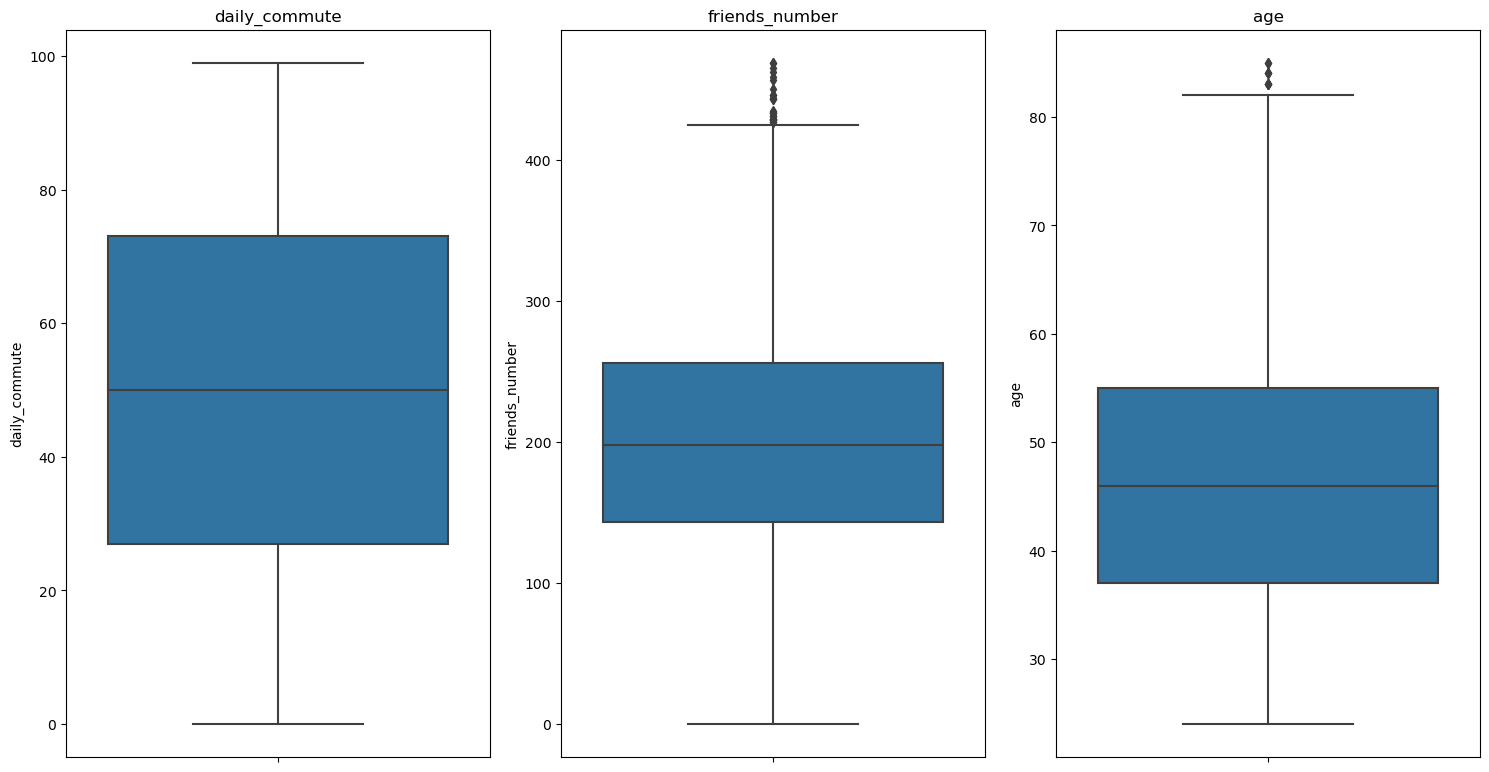

In [354]:
plt.figure(figsize=(15,90))
plotnumber = 1
for outliers in outlier_check:
    ax = plt.subplot(12,3,plotnumber)
    sns.boxplot(y = outliers, data = train)
    plt.title(outliers)
    plotnumber+=1
plt.tight_layout()
plt.show()

# Review and visualization of data

In [355]:
train1 = train[train['target'] == 1]
train0 = train[train['target'] == 0]

In [356]:
train1.columns.max()

'user_id'

In [357]:
train0.describe().round()

,user_id,target,location_population,location_from_population,daily_commute,friends_number,relationship_status,education,credit_card_type,groups,age
count,3173.0,3173.0,3173.0,3173.0,3173.0,3173.0,3173.0,3173.0,3173.0,3173.0,3173.0
mean,1988.0,0.0,287487.0,292021.0,50.0,200.0,2.0,4.0,2.0,4.0,48.0
std,1151.0,0.0,464982.0,471090.0,28.0,97.0,1.0,1.0,1.0,2.0,13.0
min,1.0,0.0,786.0,1031.0,0.0,0.0,0.0,1.0,0.0,0.0,24.0
25%,985.0,0.0,23809.0,25533.0,27.0,130.0,1.0,3.0,1.0,3.0,39.0
50%,1994.0,0.0,73791.0,74834.0,50.0,200.0,2.0,4.0,2.0,4.0,47.0
75%,2966.0,0.0,339850.0,339850.0,73.0,268.0,3.0,5.0,3.0,5.0,57.0
max,3998.0,0.0,1764615.0,1764615.0,99.0,469.0,4.0,6.0,3.0,9.0,85.0


In [358]:
train1.describe().round()

,user_id,target,location_population,location_from_population,daily_commute,friends_number,relationship_status,education,credit_card_type,groups,age
count,806.0,806.0,806.0,806.0,806.0,806.0,806.0,806.0,806.0,806.0,806.0
mean,2044.0,1.0,400342.0,287104.0,50.0,197.0,2.0,4.0,2.0,6.0,40.0
std,1168.0,0.0,559845.0,476282.0,28.0,41.0,1.0,1.0,1.0,2.0,12.0
min,0.0,1.0,1391.0,1391.0,0.0,73.0,0.0,1.0,0.0,1.0,24.0
25%,1067.0,1.0,30207.0,21534.0,27.0,171.0,1.0,3.0,1.0,4.0,29.0
50%,2016.0,1.0,113621.0,65088.0,50.0,196.0,2.0,4.0,2.0,5.0,39.0
75%,3109.0,1.0,638586.0,339850.0,75.0,226.0,4.0,5.0,3.0,7.0,48.0
max,3999.0,1.0,1764615.0,1764615.0,99.0,328.0,4.0,6.0,3.0,11.0,81.0


In [359]:
train_summary = train.groupby('target')
train_summary.mean().round()

,user_id,location_population,location_from_population,daily_commute,friends_number,relationship_status,education,credit_card_type,groups,age
target,,,,,,,,,,
0,1988.0,287487.0,292021.0,50.0,200.0,2.0,4.0,2.0,4.0,48.0
1,2044.0,400342.0,287104.0,50.0,197.0,2.0,4.0,2.0,6.0,40.0


In [360]:
train.head(2)

,user_id,target,name,sex,location,location_population,location_from,location_from_population,occupation,hobbies,daily_commute,friends_number,relationship_status,education,credit_card_type,groups,age,location_type,location_from_type
0,0,1,Halina,female,Piastów,22732,Piastów,22732,Teaching professionals,Fitness,46.0,196.0,4.0,3.0,3.0,4,43.0,2,2
1,1,0,Eustachy,male,Sokółka,18331,Sokółka,18331,General and keyboard clerks,"LARPing,Foreign language learning,Netball",55.0,243.0,4.0,4.0,2.0,5,54.0,2,2


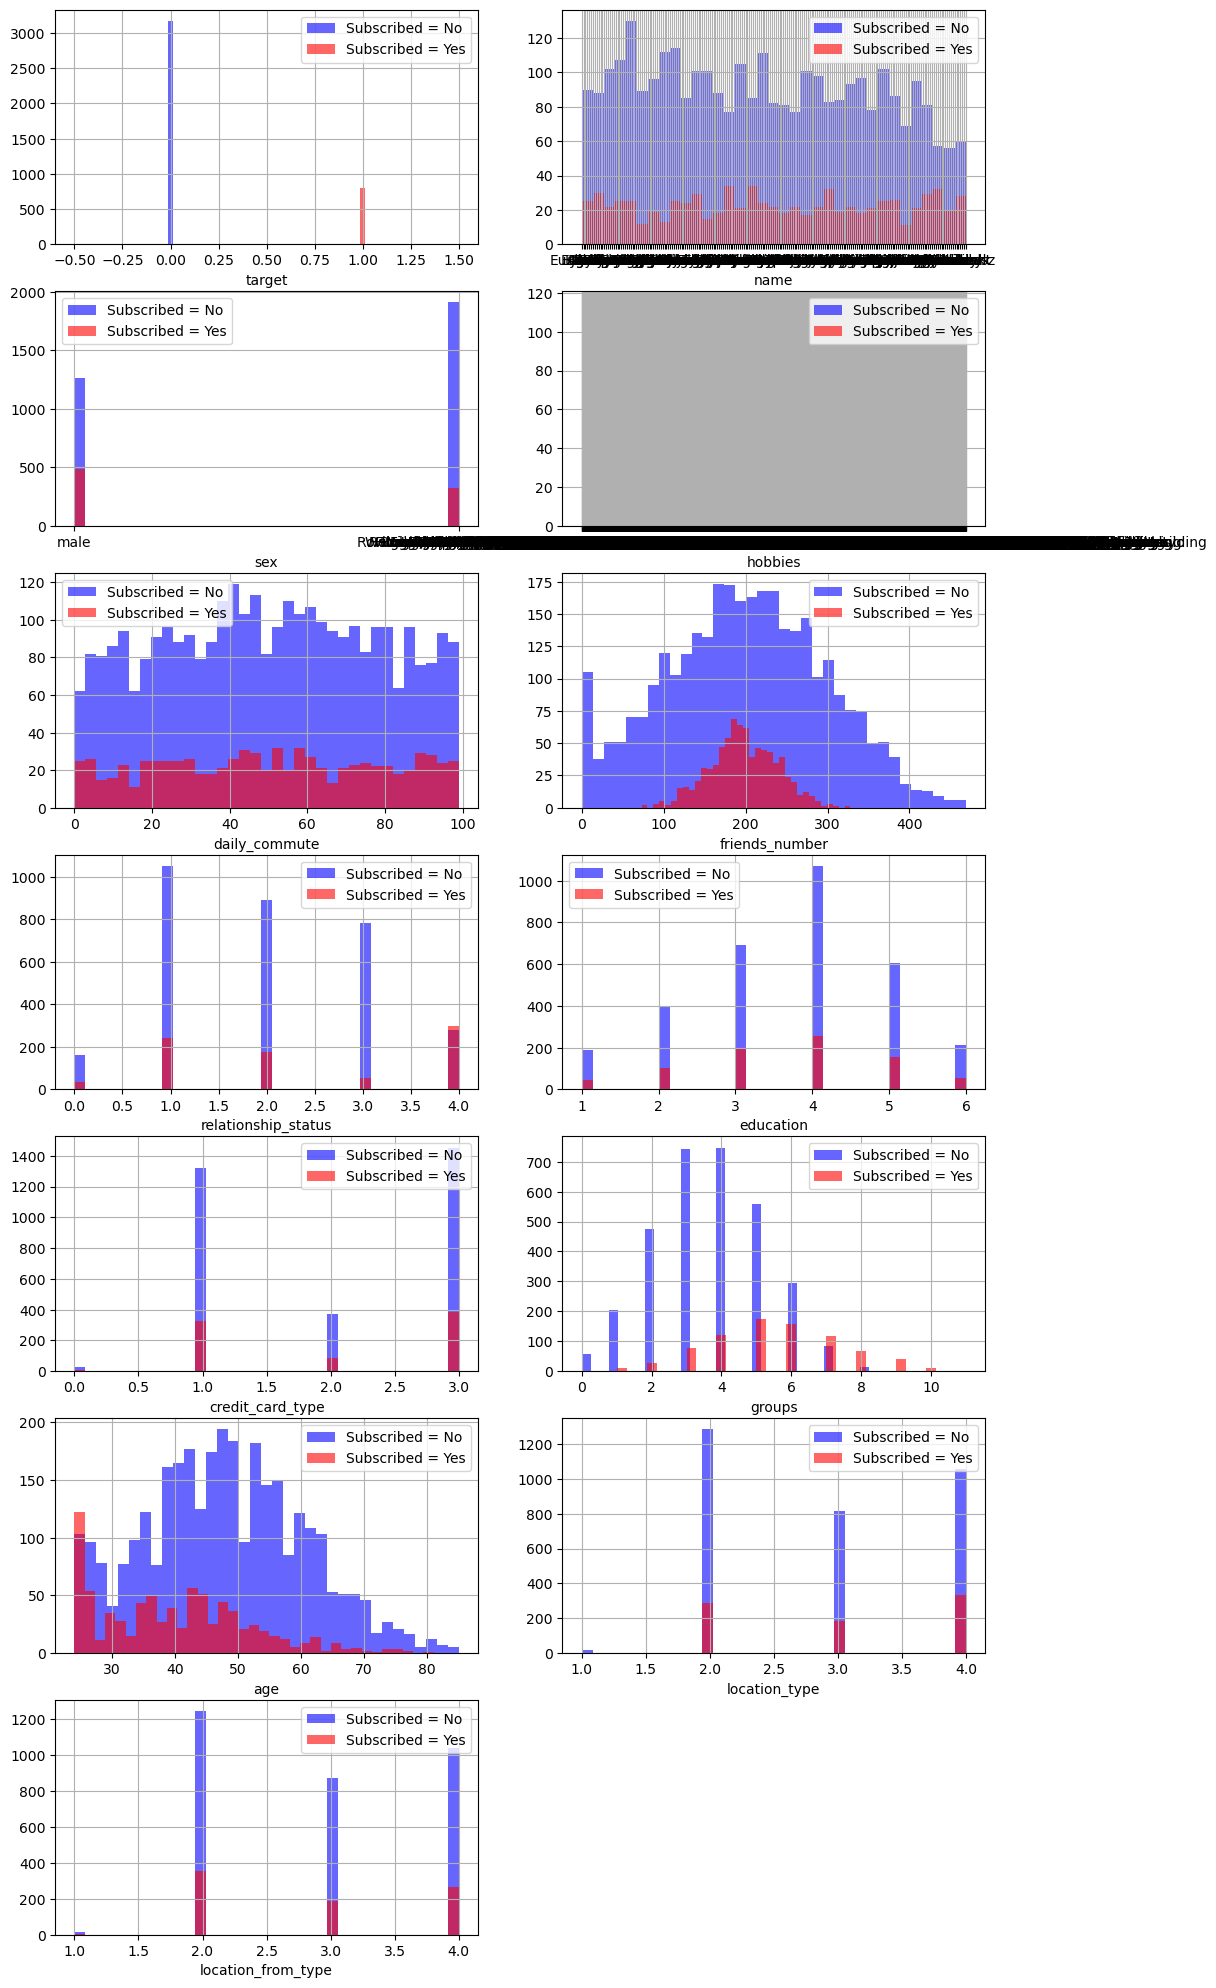

In [361]:
# this histogram helps visualize how each variable differs between the two target classes and identifies features 
#that may be useful #for prediction.
del_col = ['user_id', 'location', 'location_population', 'location_from_population', 'occupation', 'location_from']
columns = train.drop(del_col, axis=1).columns
plt.figure(figsize=(12, 25))

for i, column in enumerate(columns, 1):
    plt.subplot(7, 2, i)
    train[train["target"] == 0][column].hist(bins=35, color='blue', label='Subscribed = No', alpha=0.6)
    train[train["target"] == 1][column].hist(bins=35, color='red', label='Subscribed = Yes', alpha=0.6)
    plt.legend()
    plt.xlabel(column)

In [362]:
train_summary.median()

,user_id,location_population,location_from_population,daily_commute,friends_number,relationship_status,education,credit_card_type,groups,age
target,,,,,,,,,,
0,1994.0,73791.0,74834.0,50.0,200.0,2.0,4.0,2.0,4.0,47.2
1,2016.5,113621.0,65088.5,50.0,196.0,2.0,4.0,2.0,5.0,39.1


## Correlation

Based on the table and the plots, we can observe that the features with the strongest relationship to the target variable are age and groups.
In contrast, education, friends_number, and location_from_population show the weakest correlation with the target.

**Positive correlation:**

Users who belong to more groups tend to show a higher interest in subscribing to a long-term gym program.
Additionally, users living in larger cities also demonstrate slightly higher subscription rates.

**Negative correlation:**

The data suggests that younger customers are more likely to subscribe, indicating a negative relationship between age and the likelihood of subscription.

In [364]:
train.corr()

#no strong correlations between different variables. Strongest correlation is bwteeen location_from_population and location_population.
#meaning that many users didn't move to different city.

,user_id,target,location_population,location_from_population,daily_commute,friends_number,relationship_status,education,credit_card_type,groups,age
user_id,1.000000,0.019517,-0.008943,-0.025525,0.009214,0.020455,-0.004461,-0.039330,0.003371,-0.003167,-0.011193
target,0.019517,1.000000,0.093008,-0.004186,0.004456,-0.009838,0.152084,-0.001714,0.011991,0.414372,-0.243750
location_population,-0.008943,0.093008,1.000000,0.477286,0.009381,0.003291,0.027025,0.020391,0.003671,0.054473,-0.021891
location_from_population,-0.025525,-0.004186,0.477286,1.000000,0.000895,0.011422,0.005112,0.028832,-0.003106,0.005446,-0.015066
daily_commute,0.009214,0.004456,0.009381,0.000895,1.000000,-0.007094,0.007388,-0.021928,-0.000392,0.018664,0.018823
friends_number,0.020455,-0.009838,0.003291,0.011422,-0.007094,1.000000,0.028202,0.020349,0.027115,-0.015542,0.027681
relationship_status,-0.004461,0.152084,0.027025,0.005112,0.007388,0.028202,1.000000,-0.033102,0.030269,0.101747,-0.049300
education,-0.039330,-0.001714,0.020391,0.028832,-0.021928,0.020349,-0.033102,1.000000,0.029496,-0.015393,0.012766
credit_card_type,0.003371,0.011991,0.003671,-0.003106,-0.000392,0.027115,0.030269,0.029496,1.000000,0.021809,-0.006229
groups,-0.003167,0.414372,0.054473,0.005446,0.018664,-0.015542,0.101747,-0.015393,0.021809,1.000000,-0.107507


<Axes: title={'center': 'Correlation with response variable'}>

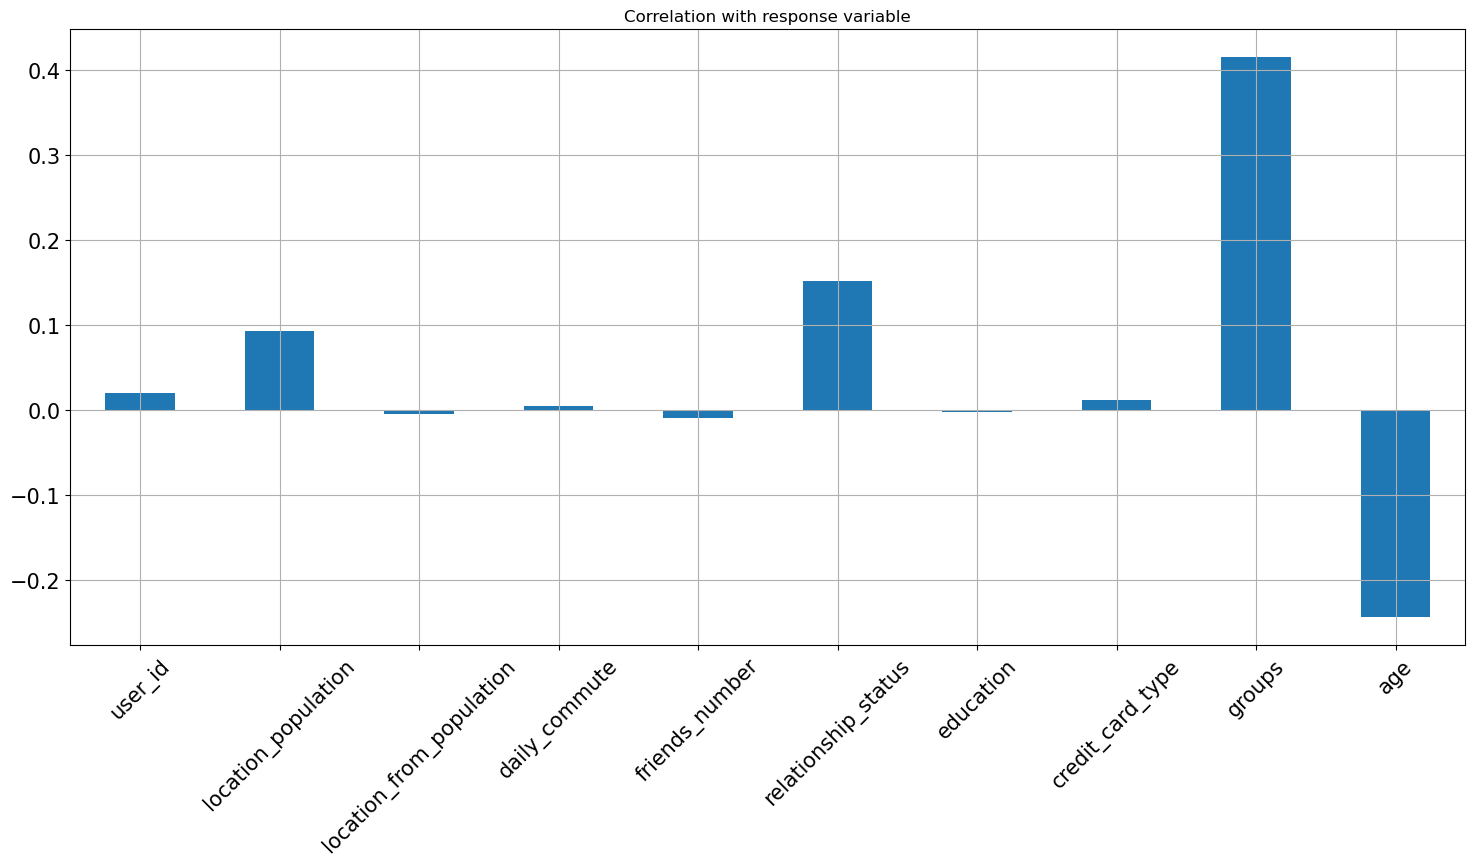

In [365]:
train.drop('target', axis=1).corrwith(train.target).plot.bar(figsize = (18,8),
                                                     title = 'Correlation with response variable',
                                                     fontsize = 15, rot = 45,
                                                     grid = True)

The correlation heatmap shows that most features have only a weak relationship with the target variable.
However, two variables stand out:

Groups shows the strongest positive correlation with the target (+0.41).
Users who belong to more groups are more likely to subscribe.

Age has a moderate negative correlation with the target (–0.24).
Younger users show a higher tendency to subscribe.

Additionally, the features location_population and location_from_population are strongly correlated with each other (+0.48), which is expected due to their demographic nature.

<Axes: >

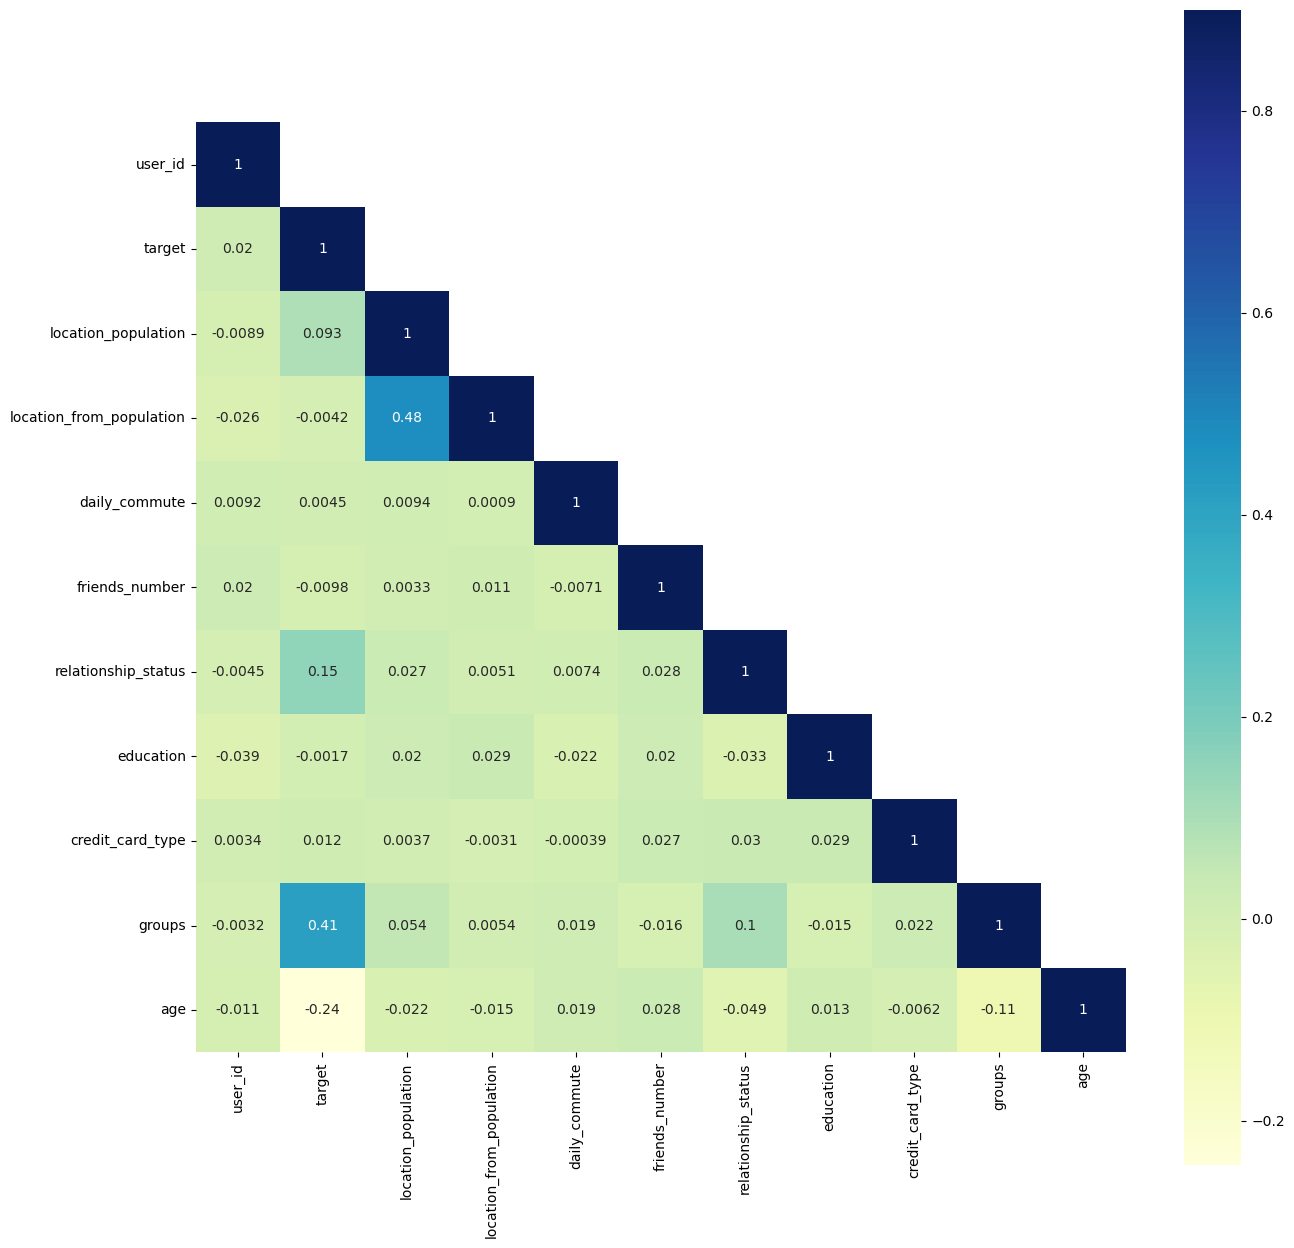

In [366]:
corr = train.corr()
mask = np.array(corr)
mask[np.tril_indices_from(mask)] = False
fig,ax= plt.subplots()
fig.set_size_inches(15,15)
sns.heatmap(corr, mask=mask,vmax=.9, square=True,annot=True, cmap="YlGnBu")

In [367]:
categorical_features = ['sex', 'relationship_status', 'credit_card_type', 'location_type', 'location_from_type', \
                        'education']

In [368]:
train0['occupation'].value_counts().head()

Science and engineering associate professionals                                      87
Health associate professionals                                                       86
Business and administration professionals                                            84
Food processing, wood working, garment and other craft and related trades workers    83
General and keyboard clerks                                                          83
Name: occupation, dtype: int64

In [369]:
train1['occupation'].value_counts().head()

Handicraft and printing workers                                28
Non-commissioned armed forces officers                         27
Refuse workers and other elementary workers                    25
Building and related trades workers, excluding electricians    24
Armed forces occupations, other ranks                          23
Name: occupation, dtype: int64

In [370]:
numerical_features=['daily_commute', 'friends_number', 'age']

In [371]:
train.head()

,user_id,target,name,sex,location,location_population,location_from,location_from_population,occupation,hobbies,daily_commute,friends_number,relationship_status,education,credit_card_type,groups,age,location_type,location_from_type
0,0,1,Halina,female,Piastów,22732,Piastów,22732,Teaching professionals,Fitness,46.0,196.0,4.0,3.0,3.0,4,43.0,2,2
1,1,0,Eustachy,male,Sokółka,18331,Sokółka,18331,General and keyboard clerks,"LARPing,Foreign language learning,Netball",55.0,243.0,4.0,4.0,2.0,5,54.0,2,2
2,2,1,Egon,male,Łaskarzew,4879,Łaskarzew,4879,Protective services workers,"Bodybuilding,Kabaddi",90.0,191.0,1.0,3.0,2.0,4,25.0,2,2
3,3,0,Eulalia,female,Bydgoszcz,352313,Bydgoszcz,352313,Customer services clerks,Badminton,88.0,164.0,1.0,3.0,3.0,3,33.0,4,4
4,4,0,Hilary,male,Osieczna,2322,Poznań,538633,Refuse workers and other elementary workers,"Fitness,Embroidery,Lacemaking",40.0,119.0,3.0,5.0,2.0,7,50.0,2,4


# Splitting hobby column/ dummy data

In [372]:
hobbies = train[['user_id', 'hobbies']]
hobbies.head(20)

,user_id,hobbies
0,0,Fitness
1,1,"LARPing,Foreign language learning,Netball"
2,2,"Bodybuilding,Kabaddi"
3,3,Badminton
4,4,"Fitness,Embroidery,Lacemaking"
5,5,"Rowing,Amateur radio,Sudoku"
6,6,"Gym,3D printing,Gaming,Flag Football"
7,7,"Crossfit,3D printing,Coloring,Hooping"
8,8,"Badminton,Listening to music"
9,9,Kettleballs


In [373]:

# Rozdzielamy hobby i tworzymy listę unikalnych hobby
hobbies['hobbies'] = hobbies['hobbies'].fillna('')
hobbies['hobbies'] = hobbies['hobbies'].str.split(',')
all_hobbies = sorted(set(hobby for sublist in hobbies['hobbies'] for hobby in sublist if hobby))

# Tworzymy nowy DataFrame z kolumnami dla każdego hobby
hobby_df = pd.DataFrame(0, index=hobbies['user_id'], columns=all_hobbies)


# Wypełniamy DataFrame odpowiednimi wartościami
for idx, row in hobbies.iterrows():
    for hobby in row['hobbies']:
        if hobby:
            hobby_df.at[row['user_id'], hobby] = 1

# Dodajemy kolumnę user_id
hobby_df = hobby_df.reset_index().rename(columns={'index': 'user_id'})

In [374]:
hobby_df

,user_id,3D printing,Acting,Air sports,Amateur radio,Archery,Astronomy,BASE jumping,Backpacking,Badminton,...,Wood carving,Woodworking,Worldbuilding,Writing,Yo-yoing,Yoga,amateur radio,role-playing games,scrapbook,tabletop games
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,3,0,0,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
4,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3974,3995,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3975,3996,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3976,3997,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3977,3998,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [375]:
train.head()

,user_id,target,name,sex,location,location_population,location_from,location_from_population,occupation,hobbies,daily_commute,friends_number,relationship_status,education,credit_card_type,groups,age,location_type,location_from_type
0,0,1,Halina,female,Piastów,22732,Piastów,22732,Teaching professionals,Fitness,46.0,196.0,4.0,3.0,3.0,4,43.0,2,2
1,1,0,Eustachy,male,Sokółka,18331,Sokółka,18331,General and keyboard clerks,"LARPing,Foreign language learning,Netball",55.0,243.0,4.0,4.0,2.0,5,54.0,2,2
2,2,1,Egon,male,Łaskarzew,4879,Łaskarzew,4879,Protective services workers,"Bodybuilding,Kabaddi",90.0,191.0,1.0,3.0,2.0,4,25.0,2,2
3,3,0,Eulalia,female,Bydgoszcz,352313,Bydgoszcz,352313,Customer services clerks,Badminton,88.0,164.0,1.0,3.0,3.0,3,33.0,4,4
4,4,0,Hilary,male,Osieczna,2322,Poznań,538633,Refuse workers and other elementary workers,"Fitness,Embroidery,Lacemaking",40.0,119.0,3.0,5.0,2.0,7,50.0,2,4


In [376]:

train['occupation'].value_counts()

Science and engineering associate professionals                                      105
Health associate professionals                                                       104
Information and communications technicians                                           103
Food processing, wood working, garment and other craft and related trades workers    103
Information and communications technology professionals                              102
General and keyboard clerks                                                          102
Refuse workers and other elementary workers                                          101
Legal, social, cultural and related associate professionals                          100
Handicraft and printing workers                                                      100
Non-commissioned armed forces officers                                               100
Armed forces occupations, other ranks                                                100
Protective services w

## Removing columns - name and hobbies

In [377]:
# The 'occupation' variable contains a large number of highly diverse categories,
# each occurring with relatively low frequency. Such high-cardinality categorical 
# features are difficult to encode meaningfully and are unlikely to contribute 
# significantly to model performance.

# The 'hobbies' feature also contains many missing values and extremely diverse 
# categories, making reliable imputation or encoding impractical.

# Therefore, both variables are excluded from further modeling.
train.drop(['name', 'hobbies'], axis=1, inplace=True)

In [378]:
train.isnull().sum()

user_id                     0
target                      0
sex                         0
location                    0
location_population         0
location_from               0
location_from_population    0
occupation                  0
daily_commute               0
friends_number              0
relationship_status         0
education                   0
credit_card_type            0
groups                      0
age                         0
location_type               0
location_from_type          0
dtype: int64

In [379]:
train.head()

,user_id,target,sex,location,location_population,location_from,location_from_population,occupation,daily_commute,friends_number,relationship_status,education,credit_card_type,groups,age,location_type,location_from_type
0,0,1,female,Piastów,22732,Piastów,22732,Teaching professionals,46.0,196.0,4.0,3.0,3.0,4,43.0,2,2
1,1,0,male,Sokółka,18331,Sokółka,18331,General and keyboard clerks,55.0,243.0,4.0,4.0,2.0,5,54.0,2,2
2,2,1,male,Łaskarzew,4879,Łaskarzew,4879,Protective services workers,90.0,191.0,1.0,3.0,2.0,4,25.0,2,2
3,3,0,female,Bydgoszcz,352313,Bydgoszcz,352313,Customer services clerks,88.0,164.0,1.0,3.0,3.0,3,33.0,4,4
4,4,0,male,Osieczna,2322,Poznań,538633,Refuse workers and other elementary workers,40.0,119.0,3.0,5.0,2.0,7,50.0,2,4


# 4. Model Building - preparing data sets
In this step, the categorical variables (sex, occupation, relationship_status, credit_card_type) were transformed into numerical values using Label Encoding.
A separate mapping for each feature was generated to keep track of how categories were converted.
After encoding the dataset, the target variable was separated into labels, and the remaining features formed the training input data.

In [380]:
train_data = train[['target', 'sex', 'occupation', 'daily_commute', 'friends_number', 'relationship_status', 'education', \
             'credit_card_type', 'age', 'location_type', 'location_from_type', 'groups']]
train_data

,target,sex,occupation,daily_commute,friends_number,relationship_status,education,credit_card_type,age,location_type,location_from_type,groups
0,1,female,Teaching professionals,46.0,196.0,4.0,3.0,3.0,43.0,2,2,4
1,0,male,General and keyboard clerks,55.0,243.0,4.0,4.0,2.0,54.0,2,2,5
2,1,male,Protective services workers,90.0,191.0,1.0,3.0,2.0,25.0,2,2,4
3,0,female,Customer services clerks,88.0,164.0,1.0,3.0,3.0,33.0,4,4,3
4,0,male,Refuse workers and other elementary workers,40.0,119.0,3.0,5.0,2.0,50.0,2,4,7
...,...,...,...,...,...,...,...,...,...,...,...,...
3995,1,male,"Market-oriented skilled forestry, fishery and ...",1.0,126.0,2.0,5.0,1.0,40.0,2,2,3
3996,0,female,"Building and related trades workers, excluding...",65.0,121.0,4.0,2.0,3.0,40.0,4,4,1
3997,1,female,Personal service workers,79.0,140.0,4.0,4.0,3.0,59.0,3,2,6
3998,0,female,Handicraft and printing workers,30.0,272.0,0.0,6.0,1.0,54.0,4,3,5


In [381]:
train_data.isnull().sum()

target                 0
sex                    0
occupation             0
daily_commute          0
friends_number         0
relationship_status    0
education              0
credit_card_type       0
age                    0
location_type          0
location_from_type     0
groups                 0
dtype: int64

In [382]:
#categorical variable
cat_var = ['sex', 'occupation', 'relationship_status', 'credit_card_type']

In [383]:
le = LabelEncoder()

for feature in cat_var:
    print(feature)
    train_data[feature] = le.fit_transform( train_data[feature])
    integer_mapping = {l: i for i, l in enumerate(le.classes_)}
    print(integer_mapping)
    print()

sex
{'female': 0, 'male': 1}

occupation
{'Administrative and commercial managers': 0, 'Agricultural, forestry and fishery labourers': 1, 'Armed forces occupations, other ranks': 2, 'Assemblers': 3, 'Building and related trades workers, excluding electricians': 4, 'Business and administration associate professionals': 5, 'Business and administration professionals': 6, 'Chief executives, senior officials and legislators': 7, 'Cleaners and helpers': 8, 'Commissioned armed forces officers': 9, 'Customer services clerks': 10, 'Drivers and mobile plant operators': 11, 'Electrical and electronic trades workers': 12, 'Food preparation assistants': 13, 'Food processing, wood working, garment and other craft and related trades workers': 14, 'General and keyboard clerks': 15, 'Handicraft and printing workers': 16, 'Health associate professionals': 17, 'Health professionals': 18, 'Hospitality, retail and other services managers': 19, 'Information and communications technicians': 20, 'Information 

In [384]:
train_data

,target,sex,occupation,daily_commute,friends_number,relationship_status,education,credit_card_type,age,location_type,location_from_type,groups
0,1,0,42,46.0,196.0,4,3.0,3,43.0,2,2,4
1,0,1,15,55.0,243.0,4,4.0,2,54.0,2,2,5
2,1,1,34,90.0,191.0,1,3.0,2,25.0,2,2,4
3,0,0,10,88.0,164.0,1,3.0,3,33.0,4,4,3
4,0,1,35,40.0,119.0,3,5.0,2,50.0,2,4,7
...,...,...,...,...,...,...,...,...,...,...,...,...
3995,1,1,26,1.0,126.0,2,5.0,1,40.0,2,2,3
3996,0,0,4,65.0,121.0,4,2.0,3,40.0,4,4,1
3997,1,0,32,79.0,140.0,4,4.0,3,59.0,3,2,6
3998,0,0,16,30.0,272.0,0,6.0,1,54.0,4,3,5


In [385]:
labels = train_data['target']

In [386]:
train_data = train_data.drop(['target'],axis = 1)

In [387]:
labels

0       1
1       0
2       1
3       0
4       0
       ..
3995    1
3996    0
3997    1
3998    0
3999    1
Name: target, Length: 3979, dtype: int64

# 5.  a) Logistic Regression

In [388]:
from sklearn.metrics import accuracy_score
from sklearn.tree import DecisionTreeClassifier

In [389]:
lr = LogisticRegression()

In [390]:
X = np.asarray(train_data)
X[0:5]

array([[  0.,  42.,  46., 196.,   4.,   3.,   3.,  43.,   2.,   2.,   4.],
       [  1.,  15.,  55., 243.,   4.,   4.,   2.,  54.,   2.,   2.,   5.],
       [  1.,  34.,  90., 191.,   1.,   3.,   2.,  25.,   2.,   2.,   4.],
       [  0.,  10.,  88., 164.,   1.,   3.,   3.,  33.,   4.,   4.,   3.],
       [  1.,  35.,  40., 119.,   3.,   5.,   2.,  50.,   2.,   4.,   7.]])

In [391]:
y = np.asarray(labels)
y

array([1, 0, 1, ..., 1, 0, 1], dtype=int64)

In [392]:
#normalize the dataset:
#from sklearn import preprocessing
#X = preprocessing.StandardScaler().fit(X).transform(X)
#X[0:5]

## Split dataset into training and test set

In [393]:
#The dataset is divided into training (80%) and test (20%) subsets using train_test_split.
#This allows us to train the model on one part of the data and evaluate its performance on unseen samples.

X_train, x_test, Y_train, y_test = train_test_split( X, y,test_size=0.2, random_state=4)

print ('Train set:', X_train.shape,  Y_train.shape)
print ('Test set:', x_test.shape,  y_test.shape)

Train set: (3183, 11) (3183,)
Test set: (796, 11) (796,)


In [394]:
LR = LogisticRegression(C=0.01, solver='liblinear').fit(X_train,Y_train)
LR

LogisticRegression(C=0.01, solver='liblinear')

In [395]:
prediction = LR.predict(x_test)

In [396]:
# After training, the model predicts class labels for the test set using predict().
# Additionally, predict_proba() is used to obtain the predicted probability of each class, which is useful for evaluating model confidence.

prediction_prob = LR.predict_proba(x_test)
prediction_prob

array([[0.88, 0.12],
       [0.98, 0.02],
       [1.  , 0.  ],
       ...,
       [0.92, 0.08],
       [0.95, 0.05],
       [0.98, 0.02]])

## Evaluation of logistic model

The model performance is assessed using the Jaccard Score, which measures how well the predicted labels match the true labels.
A score close to 1 indicates good prediction accuracy, while 0 indicates poor performance.

In [397]:
jaccard_score(y_test, prediction ,pos_label=0)

0.8384925975773889

Confusion matrix, without normalization
[[ 53 102]
 [ 18 623]]


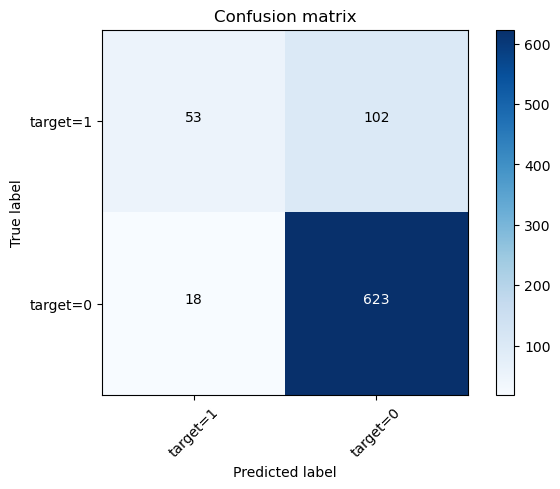

In [398]:
# Compute confusion matrix
cnf_matrix = confusion_matrix(y_test, prediction, labels=[1,0])
np.set_printoptions(precision=2)


# Plot non-normalized confusion matrix
plt.figure()
plot_confusion_matrix(cnf_matrix, classes=['target=1','target=0'],normalize= False,  title='Confusion matrix')


Based on matrix we can see that there are:
- 492 true negatives
- 55 true positives
- 89 false negatives
- 26 false positives


In [399]:
print (classification_report(y_test, prediction))

              precision    recall  f1-score   support

           0       0.86      0.97      0.91       641
           1       0.75      0.34      0.47       155

    accuracy                           0.85       796
   macro avg       0.80      0.66      0.69       796
weighted avg       0.84      0.85      0.83       796



Precision is a measure of the accuracy provided that a class label has been predicted. 

Recall is the true positive rate.

The F1 score is the harmonic average of the precision and recall, where an F1 score reaches its best value at 1 (perfect precision and recall) and worst at 0.

## log loss
 Log loss( Logarithmic loss) measures the performance of a classifier where the predicted output is a probability value between 0 and 1.

In [400]:
log_loss(y_test, prediction_prob)

0.3623124072752087

In [401]:
Xlog = sm.add_constant(train_data) 
logr_model = sm.Logit(labels, Xlog)


In [402]:
#checking which columns are not important to establish probablity
logr_fit = logr_model.fit()
print(logr_fit.pvalues > 0.05)

Optimization terminated successfully.
         Current function value: 0.372481
         Iterations 7
const                  False
sex                    False
occupation              True
daily_commute           True
friends_number          True
relationship_status    False
education               True
credit_card_type        True
age                    False
location_type          False
location_from_type     False
groups                 False
dtype: bool


We can see thta occupation, daily commute, friends number education and credit card type are not relevant for the model and are not good predictions. 

#  b) Making predictions on test dataframe using LR model

In [403]:
test_data = test[['target', 'sex', 'occupation', 'daily_commute', 'friends_number', 'relationship_status', 'education', \
             'credit_card_type', 'age', 'location_type', 'location_from_type', 'groups']]


In [404]:
le = LabelEncoder()

for feature in cat_var:
    print(feature)
    test_data[feature] = le.fit_transform( test_data[feature])
    integer_mapping = {l: i for i, l in enumerate(le.classes_)}
    print(integer_mapping)
    print()

sex
{'female': 0, 'male': 1}

occupation
{'Administrative and commercial managers': 0, 'Agricultural, forestry and fishery labourers': 1, 'Armed forces occupations, other ranks': 2, 'Assemblers': 3, 'Building and related trades workers, excluding electricians': 4, 'Business and administration associate professionals': 5, 'Business and administration professionals': 6, 'Chief executives, senior officials and legislators': 7, 'Cleaners and helpers': 8, 'Commissioned armed forces officers': 9, 'Customer services clerks': 10, 'Drivers and mobile plant operators': 11, 'Electrical and electronic trades workers': 12, 'Food preparation assistants': 13, 'Food processing, wood working, garment and other craft and related trades workers': 14, 'General and keyboard clerks': 15, 'Handicraft and printing workers': 16, 'Health associate professionals': 17, 'Health professionals': 18, 'Hospitality, retail and other services managers': 19, 'Information and communications technicians': 20, 'Information 

In [405]:
labels_t = test_data['target']

In [406]:
test_data = test_data.drop(['target'],axis = 1)

In [407]:
test_prediction = pd.DataFrame()

In [408]:
test_prediction['user_id'] = test['user_id']

In [409]:
train_data.isnull().sum()

sex                    0
occupation             0
daily_commute          0
friends_number         0
relationship_status    0
education              0
credit_card_type       0
age                    0
location_type          0
location_from_type     0
groups                 0
dtype: int64

In [412]:
test_prediction['prob'] = LR.predict_proba(test_data)[:, 1]

In [413]:
test_prediction['classification'] = LR.predict(test_data)

In [414]:
test_prediction['classification'].value_counts()

0    1844
1     156
Name: classification, dtype: int64

In [415]:
test_prediction

,user_id,prob,classification
0,0,0.183250,0
1,1,0.354232,0
2,2,0.436721,0
3,3,0.536429,1
4,4,0.108010,0
...,...,...,...
1995,1995,0.372442,0
1996,1996,0.207612,0
1997,1997,0.228467,0
1998,1998,0.248118,0


##  Result of LR model on test data set
Based on the logistic regression model, we generated both predicted class labels and the corresponding probabilities for each user in the test dataset.

Out of 2000 users:

1844 (92.2%) were predicted not to subscribe to the service (class 0).

156 (7.8%) were predicted as potential subscribers (class 1).

These predictions are supported by the probability estimates (prob column), which indicate how likely each user is to convert.
Users with higher probability values (e.g., >0.5) are more likely to be interested in the subscription and may be prioritized for targeted marketing actions.

# 6. a) Building Decision Trees Classifier model

In [416]:
tree5 = DecisionTreeClassifier(max_depth=5, random_state=0)

In [417]:
tree5.fit(X_train,Y_train)

DecisionTreeClassifier(max_depth=5, random_state=0)

In [418]:
predict = tree5.predict(x_test)

In [419]:
accuracy_score(y_test, predict)

0.8492462311557789

In [420]:
tree4 = DecisionTreeClassifier(max_depth=4, random_state=0) #tree

In [421]:
tree4.fit(X_train,Y_train)

DecisionTreeClassifier(max_depth=4, random_state=0)

In [422]:
predict = tree4.predict(x_test)

In [423]:
accuracy_score(y_test, predict)

0.8467336683417085

In [424]:
#calculating accuracy for each depth

#we can see that highets accuracy is for depth 5

depth = [3, 4, 5, 6, 7]

for d in depth:
    tree = DecisionTreeClassifier(max_depth=d, random_state=0) #tree
    tree.fit(X_train,Y_train)
    predict = tree.predict(x_test)
    ac = accuracy_score(y_test, predict)
    print(ac)

0.8454773869346733
0.8467336683417085
0.8492462311557789
0.8442211055276382
0.8530150753768844


In [425]:
import sklearn.tree as tree

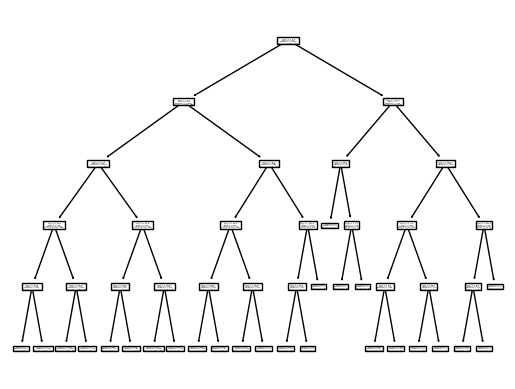

In [426]:
tree.plot_tree(tree5)
plt.show()

In [427]:
#checking the time of training
t0 = time.time()
tree5.fit(X_train, Y_train)
sklearn_time = time.time()-t0
print("[Scikit-Learn] Training time (s):  {0:.5f}".format(sklearn_time))

[Scikit-Learn] Training time (s):  0.02920


In [428]:
prediction_prob_tree = tree5.predict_proba(x_test)[:,1]

In [429]:
# Curve (ROC-AUC) score from the predictions
tree_roc_auc = roc_auc_score(y_test, prediction_prob_tree)
print('[Scikit-Learn] ROC-AUC score : {0:.3f}'.format(tree_roc_auc))

[Scikit-Learn] ROC-AUC score : 0.826


Confusion matrix, without normalization
[[ 61  94]
 [ 23 618]]


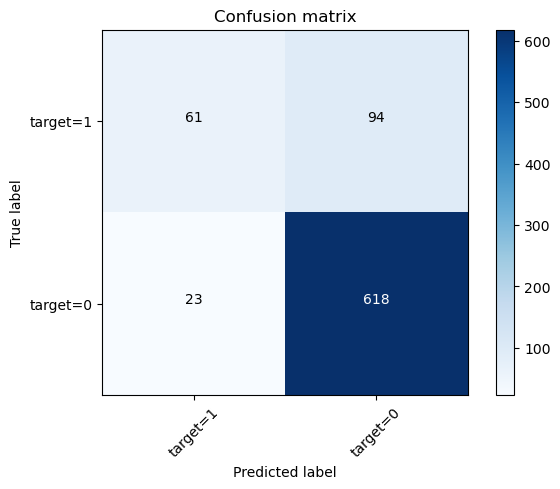

In [430]:
# Compute confusion matrix
cnf_matrix = confusion_matrix(y_test, predict, labels=[1,0])
np.set_printoptions(precision=2)


# Plot non-normalized confusion matrix
plt.figure()
plot_confusion_matrix(cnf_matrix, classes=['target=1','target=0'],normalize= False,  title='Confusion matrix')


Based on matrix we can see that there are:
- 473 true negatives
- 80 true positives
- 64 false negatives
- 45 false positives

In [431]:
print (classification_report(y_test, predict))

              precision    recall  f1-score   support

           0       0.87      0.96      0.91       641
           1       0.73      0.39      0.51       155

    accuracy                           0.85       796
   macro avg       0.80      0.68      0.71       796
weighted avg       0.84      0.85      0.84       796



# b)  Making predictions on test dataframe using Decision Tree model

In [432]:
test_prediction_tree = pd.DataFrame()

In [433]:
test_prediction_tree['user_id'] = test['user_id']

In [434]:
test_prediction_tree['prob']= tree5.predict_proba(test_data)[:,1]

In [435]:
test_prediction_tree['classification'] = tree5.predict(test_data)

In [436]:
test_prediction_tree

,user_id,prob,classification
0,0,0.552147,1
1,1,0.955556,1
2,2,0.644444,1
3,3,0.650000,1
4,4,0.067753,0
...,...,...,...
1995,1995,0.220137,0
1996,1996,0.220137,0
1997,1997,0.067753,0
1998,1998,0.020833,0


In [437]:
test_prediction_tree['classification'].value_counts()

0    1673
1     327
Name: classification, dtype: int64

##  Result of Decision Tree model on test data set

The Decision Tree classifier was evaluated on the test dataset and achieved the following performance:

Accuracy: 0.84

Precision (class 1 – subscribers): 0.64

Recall (class 1): 0.56

F1-score (class 1): 0.59

Compared to Logistic Regression, the Decision Tree model shows an improvement in identifying potential subscribers (class 1). Specifically:

It increases recall for class 1 from 0.38 to 0.56, meaning it is able to find more true subscribers.

It also improves the F1-score for class 1 from 0.49 → 0.59, providing a better balance between precision and recall.

The accuracy is slightly higher (0.84 vs. 0.83), but this metric is less informative due to the class imbalance.

On the test dataset, the model predicts:

327 users as likely interested in subscription

1673 users as not interested

The probability output (prob) provides a ranking of users by their likelihood to subscribe, which can be used for targeted marketing or further segmentation.

# 7. Summary

The goal of the analysis was to build a model capable of predicting user interest in a long-term gym subscription. Two machine learning algorithms were evaluated: Logistic Regression and Decision Tree Classifier.

Model comparison
Logistic Regression

Accuracy: 0.83

F1-score (class 1): 0.49

The model performs well for class 0 (non-subscribers), but struggles to identify class 1 (subscribers), achieving a recall of only 0.38.

Decision Tree Classifier

Accuracy: 0.84

F1-score (class 1): 0.59

The Decision Tree improves significantly on class 1 recall (0.56) and overall F1-score for class 1, making it more effective at detecting potential subscribers.

Conclusion

Based on the evaluation metrics, the Decision Tree model performs better than Logistic Regression, especially in identifying users who are likely to subscribe. This is important due to the imbalanced nature of the dataset, where correctly identifying the minority class (interested users) is more valuable than maximizing overall accuracy.

### Comparison of users interested in subscription and those who are not

With a quick look on below tables we can see some significant differances between two groups.

Customers who are interested in subscription are living in bigger cities (mean population is 403182), are younger (average age is 38. We can also see that many of them are from small cities but moved to bigger ones. They are more active in social media, join more amount of groups (avergae 6). Customers who could be more interetd interested are more likely to be Men are single. 

Top 5 occupation of customers who are intereted in subscription:
- Handicraft and printing workers                                25
- Non-commissioned armed forces officers                         25
- Building and related trades workers, excluding electricians    23
- Armed forces occupations, other ranks                          21
- Refuse workers and other elementary workers                    21



Customers who are not intereted are more likely to be from smaller cities and currently living also in smaller cities. Are older than those who are interetd in subscription (average age is 44). They join less groups (average is 4). Pople who are married with kids are least likely to subscribe. Also women are less interted than men. 

Top 5 occupation of customers who are not intereted in subscription:
- Business and administration professionals             76
- Health associate professionals                        75
- Chief executives, senior officials and legislators    71
- Science and engineering associate professionals       71
- General and keyboard clerks                           69